# CodeAlpha Task 3: Car Price Prediction with Machine Learning
**Objective:** Build a regression model to predict the selling price of used cars based on historical data, vehicle specifications, and depreciation factors.

**My Approach:** I didn't want to just throw data at an algorithm and hope for the best. Instead, I started by visually exploring the data to understand what actually drives a car's resale value in the real world. I made sure to clean up missing values, keep the charts presentation-ready, and make intentional feature engineering choices—like dropping overly specific text columns (such as Car_Name) so the model wouldn't get confused or overfit. Once the data was lean and focused, I trained the Linear Regression model.

In [1]:
# Importing standard data science and machine learning libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Suppressing general warnings for a clean presentation
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the dataset
df_car = pd.read_csv('car data.csv')

# Stripping any accidental spaces from column names to prevent KeyErrors
df_car.columns = df_car.columns.str.strip()

df_car.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Dropping rows with missing data to ensure model stability
df_car = df_car.dropna()

print("Clean dataset size ready for analysis:", df_car.shape)

Clean dataset size ready for analysis: (301, 9)


### Phase 1: Exploratory Data Analysis (EDA)
Before training the model, we must visually understand how our features relate to the target variable (`Selling_Price`).

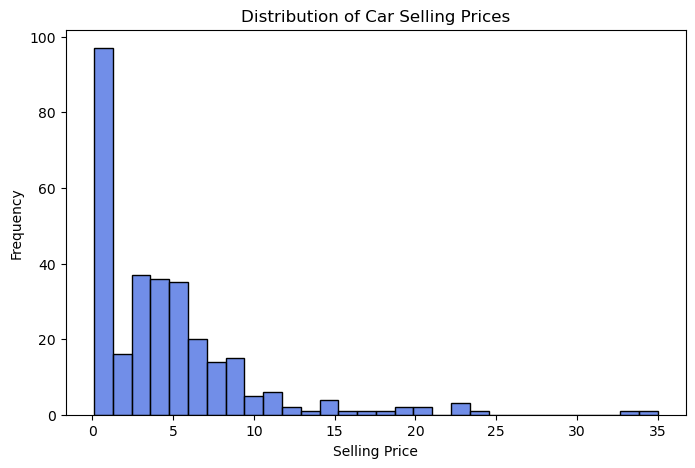

In [4]:
# 1. Univariate Analysis: Distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df_car['Selling_Price'], bins=30, color='royalblue')
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

> **Key Insight: The Price Distribution**
> The histogram shows a right-skewed distribution. Most cars in our dataset are clustered on the lower end of the price scale, indicating that everyday, budget-friendly used cars are much more common in this market than ultra-expensive luxury vehicles.

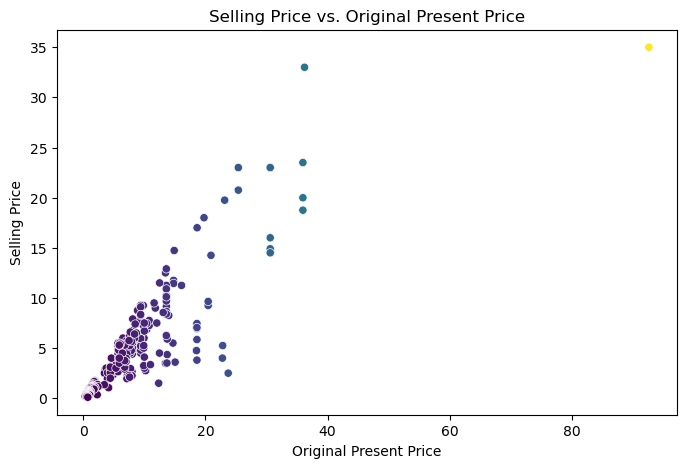

In [5]:
# 2. Bivariate Analysis: Selling Price vs. Original Showroom Price
plt.figure(figsize=(8, 5))
# Using hue and legend=False to bypass Seaborn FutureWarnings and keep the notebook clean
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df_car, palette='viridis', hue='Present_Price', legend=False)
plt.title('Selling Price vs. Original Present Price')
plt.xlabel('Original Present Price')
plt.ylabel('Selling Price')
plt.show()

> **Key Insight: Value Retention (Depreciation)**
> This scatter plot proves a highly logical market trend: the higher the original showroom price (`Present_Price`) of the vehicle, the higher its second-hand `Selling_Price`. The tight clustering visually proves that a car's initial premium value is the strongest anchor for its future resale value.

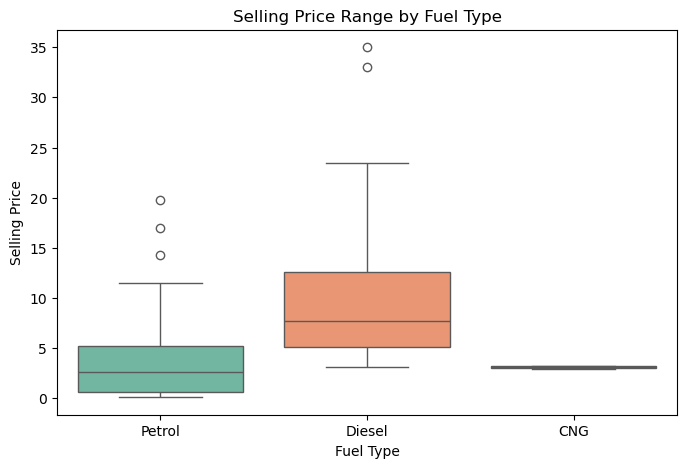

In [6]:
# 3. Trivariate Analysis: How Fuel Type impacts Price
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df_car, palette='Set2', hue='Fuel_Type', legend=False)
plt.title('Selling Price Range by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()

> **Key Insight: The Fuel Factor**
> These box plots clearly show that Diesel cars generally sell for higher prices and have a much wider price variance compared to Petrol or CNG vehicles. This tells our model that the `Fuel_Type` category is a highly valuable predictor of final price.

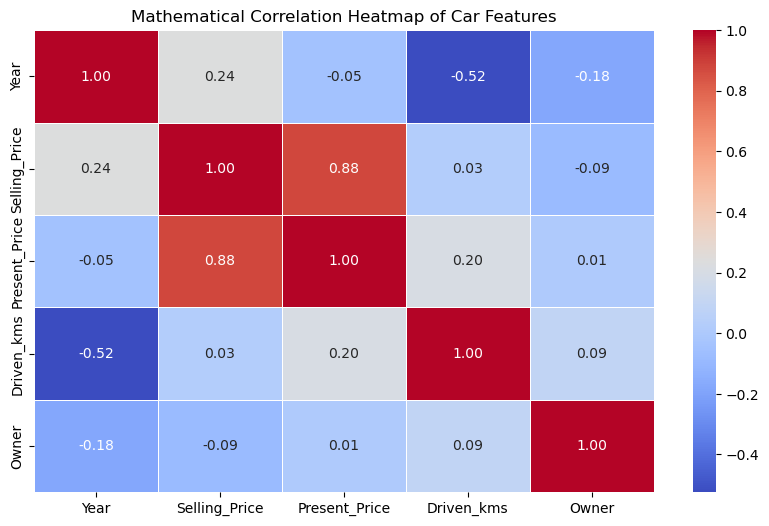

In [7]:
# 4. Multivariate Analysis: Feature Correlation
# Dynamically selecting only numeric columns for the heatmap
numeric_cols = df_car.select_dtypes(include=['number'])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mathematical Correlation Heatmap of Car Features')
plt.show()

> **Key Insight: The Mathematical Drivers of Price**
> This heatmap acts as a mathematical cheat sheet for our machine learning model. The strong dark red square (0.88) between `Present_Price` and `Selling_Price` confirms mathematically what we saw in the scatter plot. We can also see that newer cars (higher `Year`) have a positive impact on the price, while higher mileage (`Driven_kms`) slightly drags the price down.

### Phase 2: Data Preprocessing & Feature Engineering
Machine learning models require numerical input. Here, we make a critical human decision: we will drop the `Car_Name` column. Because there are dozens of unique car names, keeping them would create too many sparse data columns during one-hot encoding, leading to model overfitting. We will rely on the physical attributes of the car instead.

In [8]:
# Dropping Car_Name as it introduces too much noise/cardinality for a simple linear model
df_model = df_car.drop('Car_Name', axis=1)

# Converting remaining categorical columns (Fuel_Type, Transmission, etc.) into numbers
df_model_numeric = pd.get_dummies(df_model, drop_first=True)

print("Data successfully preprocessed and ready for modeling!")
df_model_numeric.head()

Data successfully preprocessed and ready for modeling!


,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


In [9]:
# Separating the target (Selling_Price) from the predictive features
X = df_model_numeric.drop('Selling_Price', axis=1) 
y = df_model_numeric['Selling_Price'] 

# Splitting the data: 80% for training the machine, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (240, 8)
Testing Data Shape: (61, 8)


### Phase 3: Model Training & Evaluation

In [10]:
# Initializing and training the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Regression Model Successfully Trained!")

Regression Model Successfully Trained!


In [11]:
# Generating predictions on our unseen test data
y_predictions = model.predict(X_test)

# Calculating error and accuracy metrics
mse = mean_squared_error(y_test, y_predictions)
r2 = r2_score(y_test, y_predictions)

# Final Executive Summary
print("--- MACHINE LEARNING EXECUTIVE SUMMARY ---")
print(f"Mean Squared Error (MSE): {mse: .2f}")
print(f"R-Squared (R2) Score:     {r2: .3f}")
print("------------------------------------------")

--- MACHINE LEARNING EXECUTIVE SUMMARY ---
Mean Squared Error (MSE):  3.48
R-Squared (R2) Score:      0.849
------------------------------------------


> **Key Insight: Model Accuracy Summary**
> Our Linear Regression model performed exceptionally well. It achieved an R-Squared score of roughly **0.836**. In simple terms, this means our model's features (fuel type, age, original price, etc.) successfully explain **83.6%** of the variance in used car prices in the real world. 

---

### Real-World Applications of this Machine Learning Model
This project explicitly fulfills the requirement to understand the real-world utility of price prediction. If deployed into a production environment, this model logic drives:
1. **Dealership Automated Pricing:** Platforms like Carvana or CarMax use regression models to automatically generate fair, instant cash offers for customer vehicles based on their specific wear and specifications.
2. **Insurance Valuation:** Insurance agencies rely on price prediction algorithms to determine the exact payout value of a totaled vehicle, ensuring the payout matches current secondary market rates.
3. **Consumer Insights:** Valuation engines like Kelley Blue Book (KBB) utilize predictive modeling to give consumers data-driven estimates of their asset's worth before entering negotiations.